In [ ]:
# This notebook converts preprocessed WESAD physiological windows into a handcrafted representation for classical ML classification.
# Each 30-second multimodal window (ECG, EDA, Respiration, Temperature) is transformed from 84,000 raw samples into 15 physiologically meaningful features.
# The pipeline includes feature extraction, missing-value handling, and extensive validation checks to ensure the resulting feature matrix is reliable before training the baseline model

In [ ]:
# Veryfying that the preprocessing was completed correctly for every subject, ensure the output folders exist, confirm no subjects are missing, and inspect one example to check that the shapes match the expected format.

In [ ]:
import os
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FEATURES_DIR = PROJECT_ROOT / "data" / "features"

FEATURES_DIR.mkdir(parents=True, exist_ok=True)

print("Current working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Processed directory:", PROCESSED_DIR)
print("Features directory:", FEATURES_DIR)

SUBJECT_IDS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]

missing = []

for sid in SUBJECT_IDS:
    x_path = PROCESSED_DIR / f"S{sid}_X.npy"
    y_path = PROCESSED_DIR / f"S{sid}_y.npy"

    if not x_path.exists() or not y_path.exists():
        missing.append(sid)

if missing:
    print(f"\nMissing processed files for subjects: {missing}")
    print("Go back and finish Day 3/4 preprocessing before continuing.")
else:
    print(f"\nAll {len(SUBJECT_IDS)} subjects' .npy files found.")

X_sample = np.load(PROCESSED_DIR / "S2_X.npy")
y_sample = np.load(PROCESSED_DIR / "S2_y.npy")

print(f"\nS2 shape — X: {X_sample.shape}, y: {y_sample.shape}")
print("Expected  — X: (N_windows, 4, 21000), y: (N_windows,)")

Current working directory: c:\Users\sanka\OneDrive\Desktop\mulitmodal stress detection\notebooks
Project root: c:\Users\sanka\OneDrive\Desktop\mulitmodal stress detection
Processed directory: c:\Users\sanka\OneDrive\Desktop\mulitmodal stress detection\data\processed
Features directory: c:\Users\sanka\OneDrive\Desktop\mulitmodal stress detection\data\features

All 15 subjects' .npy files found.

S2 shape — X: (140, 4, 21000), y: (140,)
Expected  — X: (N_windows, 4, 21000), y: (N_windows,)


In [ ]:
# Our dataset will consist of 30 second windows sampled at 700Hz contaiing 4 signals -ECG, EDA, Respiration & Temperature. 
# We define where each signal is stored so that the model can access them during training

In [ ]:
MODALITY_NAMES  = ["ECG", "EDA", "Respiration", "Temperature"]
MODALITY_INDEX  = {"ECG": 0, "EDA": 1, "Respiration": 2, "Temperature": 3}
FS              = 700  
WINDOW_SAMPLES  = 21000 

In [ ]:
# Loading numpy, pandas ,neurokit, welch and tqdm

In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

try:
    import neurokit2 as nk
    print("neurokit2 loaded")
except ImportError:
    print("neurokit2 not found — run: pip install neurokit2")

from scipy.signal import welch
from tqdm.notebook import tqdm

neurokit2 loaded


In [ ]:
# In this cell, we convert each 30-second ECG window into a small set of Heart Rate Variability (HRV) features that are associated with stress. 
# Rather than using all 21,000 raw ECG samples, we extract four interpretable descriptors: RMSSD, SDNN, pNN50, and Mean Heart Rate. 
# NeuroKit2 is used to detect R-peaks and compute HRV measures automatically.

# MeanHR : How fast is the heart beating?
# SDNN   : How much does the heart vary overall?
# RMSSD  : How much does one beat differ from the next?
# pNN50  : How often are heartbeat changes larger than 50 ms?

In [ ]:
def extract_ecg_features(ecg_window: np.ndarray, fs: int = 700) -> dict:
    
    feature_names = ["ECG_RMSSD", "ECG_SDNN", "ECG_pNN50", "ECG_MeanHR"]
    nan_result = {k: np.nan for k in feature_names}

    try:
        ecg_signals, info = nk.ecg_process(ecg_window, sampling_rate=fs)

        r_peaks = info["ECG_R_Peaks"]
        if len(r_peaks) < 4:
            return nan_result

        hrv = nk.hrv_time(r_peaks, sampling_rate=fs, show=False)

        mean_hr = float(ecg_signals["ECG_Rate"].mean())  

        return {
            "ECG_RMSSD"  : float(hrv["HRV_RMSSD"].values[0]),
            "ECG_SDNN"   : float(hrv["HRV_SDNN"].values[0]),
            "ECG_pNN50"  : float(hrv["HRV_pNN50"].values[0]),
            "ECG_MeanHR" : mean_hr, 
        }
    except Exception:
        return nan_result

In [ ]:
#Taking one 30-second ECG segment, extract HRV features, and confirm that our pipeline works before running it on the whole dataset.

In [ ]:
# Cell 5 — Test ECG extractor on Subject 2, window 0

X_test = np.load(PROCESSED_DIR / "S2_X.npy")

ecg_window = X_test[0, MODALITY_INDEX["ECG"], :]   # shape: (21000,)

ecg_feats = extract_ecg_features(ecg_window, fs=FS)

print("ECG features for S2, window 0:")

for k, v in ecg_feats.items():
    print(f"{k:20s} = {v:.4f}")

ECG features for S2, window 0:
ECG_RMSSD            = 52.3460
ECG_SDNN             = 72.6446
ECG_pNN50            = 14.6341
ECG_MeanHR           = 85.1365


In [ ]:
# This function does for EDA (Electrodermal Activity) what the previous one did for ECG. 
# It takes a 30-second EDA segment containing 21,000 samples and converts it into four interpretable measures of stress-related sweating activity.
#  EDA_Mean      
#  EDA_SCR_Count 
#  EDA_SCR_Amp  
#  EDA_Slope  


In [ ]:
def extract_eda_features(eda_window: np.ndarray, fs: int = 700) -> dict:
    feature_names = ["EDA_Mean", "EDA_SCR_Count", "EDA_SCR_Amp", "EDA_Slope"]
    nan_result = {k: np.nan for k in feature_names}

    try:
        eda_signals, info = nk.eda_process(eda_window, sampling_rate=fs)

        scr_peaks = info.get("SCR_Peaks", [])
        scr_count = len(scr_peaks)

        if "SCR_Amplitude" in info and len(info["SCR_Amplitude"]) == scr_count:
            scr_amplitudes = np.asarray(info["SCR_Amplitude"], dtype=float)
        elif scr_count > 0 and "EDA_Phasic" in eda_signals.columns:
            scr_amplitudes = eda_signals["EDA_Phasic"].values[
                np.asarray(scr_peaks, dtype=int)
            ]
        else:
            scr_amplitudes = np.array([np.nan])

        scr_amp_mean = (
            float(np.nanmean(scr_amplitudes))
            if len(scr_amplitudes) > 0
            else 0.0
        )

        t = np.arange(len(eda_window))
        slope = float(np.polyfit(t, eda_window, 1)[0])

        return {
            "EDA_Mean": float(np.mean(eda_window)),
            "EDA_SCR_Count": scr_count,
            "EDA_SCR_Amp": scr_amp_mean,
            "EDA_Slope": slope,
        }

    except Exception:
        return nan_result

In [9]:
eda_window = X_test[0, MODALITY_INDEX["EDA"], :]
eda_feats = extract_eda_features(eda_window, fs=FS)
print("EDA features for S2, window 0:")
for k, v in eda_feats.items():
    print(f"  {k:20s} = {v:.4f}")

EDA features for S2, window 0:
  EDA_Mean             = -0.0490
  EDA_SCR_Count        = 9.0000
  EDA_SCR_Amp          = 0.3955
  EDA_Slope            = 0.0000


In [ ]:
# This function converts a 30-second respiration signal into three features that describe how a person is breathing.
# We summarize them into: average breathing rate, variability in breathing rhythm, and average breathing depth (amplitude).


In [ ]:
def extract_resp_features(rsp_window: np.ndarray, fs: int = 700) -> dict:
    feature_names = ["RESP_Rate", "RESP_RateVar", "RESP_Amplitude"]
    nan_result = {k: np.nan for k in feature_names}

    try:
        rsp_signals, info = nk.rsp_process(rsp_window, sampling_rate=fs)

        rrv = nk.rsp_rrv(rsp_signals, sampling_rate=fs, show=False)

        rate_col = [c for c in rsp_signals.columns if "RSP_Rate" in c]
        mean_rate = (
            float(rsp_signals[rate_col[0]].mean())
            if rate_col else np.nan
        )

        amp_col = [c for c in rsp_signals.columns if "RSP_Amplitude" in c]
        mean_amp = (
            float(rsp_signals[amp_col[0]].mean())
            if amp_col else np.nan
        )

        rate_var = (
            float(rrv["RRV_RMSSD"].values[0])
            if "RRV_RMSSD" in rrv.columns
            else np.nan
        )

        return {
            "RESP_Rate": mean_rate,
            "RESP_RateVar": rate_var,
            "RESP_Amplitude": mean_amp,
        }

    except Exception:
        return nan_result

In [11]:
rsp_window = X_test[0, MODALITY_INDEX["Respiration"], :]
rsp_feats = extract_resp_features(rsp_window, fs=FS)
print("Respiration features for S2, window 0:")
for k, v in rsp_feats.items():
    print(f"  {k:25s} = {v}")

Respiration features for S2, window 0:
  RESP_Rate                 = 16.370063523712574
  RESP_RateVar              = 2807.321695502818
  RESP_Amplitude            = 3.542420082722902


In [ ]:
# This function extracts temperature-based indicators of stress from a 30-second skin temperature window. 
# Unlike ECG or EDA, temperature changes slowly and doesn't require sophisticated signal processing libraries.
# Therefore, instead of looking for complex patterns, we summarize temperature using its average value, variability, trend over time, and range of fluctuation.

#  TEMP_Mean  - average skin temperature
#  TEMP_Std   - temperature variability
#  TEMP_Slope - direction and rate of temperature change
#  TEMP_Range - total fluctuation within the window

In [ ]:
def extract_temp_features(temp_window: np.ndarray) -> dict:
    t = np.arange(len(temp_window))
    slope = float(np.polyfit(t, temp_window, 1)[0])

    return {
        "TEMP_Mean": float(np.mean(temp_window)),
        "TEMP_Std": float(np.std(temp_window)),
        "TEMP_Slope": slope,
        "TEMP_Range": float(np.max(temp_window) - np.min(temp_window)),
    }

In [13]:
temp_window = X_test[0, MODALITY_INDEX["Temperature"], :]
temp_feats = extract_temp_features(temp_window)
print("Temperature features for S2, window 0:")
for k, v in temp_feats.items():
    print(f"  {k:20s} = {v:.6f}")

Temperature features for S2, window 0:
  TEMP_Mean            = -0.582771
  TEMP_Std             = 0.021266
  TEMP_Slope           = 0.000003
  TEMP_Range           = 0.082297


In [ ]:
# This step combines handcrafted features extracted independently from ECG, EDA, respiration, and temperature into a single 15-dimensional feature vector representing one 30-second physiological window.
# This is important for training classical models

In [ ]:
def extract_all_features(window: np.ndarray, fs: int = 700) -> np.ndarray:
    
    ecg_f  = extract_ecg_features(window[0], fs=fs)
    eda_f  = extract_eda_features(window[1], fs=fs)
    resp_f = extract_resp_features(window[2], fs=fs)
    temp_f = extract_temp_features(window[3])

    feature_vector = np.array([
        ecg_f["ECG_RMSSD"],  ecg_f["ECG_SDNN"],   ecg_f["ECG_pNN50"],  ecg_f["ECG_MeanHR"],
        eda_f["EDA_Mean"],   eda_f["EDA_SCR_Count"], eda_f["EDA_SCR_Amp"], eda_f["EDA_Slope"],
        resp_f["RESP_Rate"], resp_f["RESP_RateVar"], resp_f["RESP_Amplitude"],
        temp_f["TEMP_Mean"], temp_f["TEMP_Std"],   temp_f["TEMP_Slope"], temp_f["TEMP_Range"],
    ], dtype=np.float64)

    return feature_vector

FEATURE_MODALITY_SLICES = {
    "ECG":         slice(0, 4),
    "EDA":         slice(4, 8),
    "Respiration": slice(8, 11),   
    "Temperature": slice(11, 15),
}

test_vec = extract_all_features(X_test[0])
print(f"Feature vector shape: {test_vec.shape}")
print(f"Feature values (some will be NaN if window has artifacts):")
print(test_vec)


Feature vector shape: (15,)
Feature values (some will be NaN if window has artifacts):
[ 5.23459840e+01  7.26446138e+01  1.46341463e+01  8.51364990e+01
 -4.89817522e-02  9.00000000e+00  3.95526160e-01  1.54110414e-05
  1.63700635e+01  2.80732170e+03  3.54242008e+00 -5.82771301e-01
  2.12662891e-02  2.59951993e-06  8.22974443e-02]


In [ ]:
# Missing value imputation
# Feature extraction can fail due to noisy physiological windows, producing NaN values.
# Since classical ML models cannot train with missing values, NaNs are replaced using median of each feature column

In [ ]:
def impute_nans(features: np.ndarray) -> np.ndarray:
    features = features.copy()

    for col in range(features.shape[1]):
        mask = np.isnan(features[:, col])

        if np.any(mask):
            median = np.nanmedian(features[:, col])

            if np.isnan(median):
                median = 0.0

            features[mask, col] = median

    return features

In [ ]:
# Verifying pipeline on a few subjects before processing the entire dataset
# This window verifies whether each window produces 15 feature representation , no feature is entirely NaN and physiological values fall within realistic ranges

In [ ]:
from pathlib import Path
import numpy as np

def process_subject(
    sid: int,
    processed_dir=PROCESSED_DIR,
    fs: int = 700
) -> tuple[np.ndarray, np.ndarray]:
    
    X = np.load(processed_dir / f"S{sid}_X.npy")   
    y = np.load(processed_dir / f"S{sid}_y.npy")   

    features = np.zeros((len(X), 15), dtype=np.float64)

    for i in range(len(X)):
        features[i] = extract_all_features(X[i], fs=fs)

    return features, y


feature_names_flat = [
    "ECG_RMSSD", "ECG_SDNN", "ECG_pNN50", "ECG_MeanHR",
    "EDA_Mean", "EDA_SCR_Count", "EDA_SCR_Amp", "EDA_Slope",
    "RESP_Rate", "RESP_RateVar", "RESP_Amplitude",
    "TEMP_Mean", "TEMP_Std", "TEMP_Slope", "TEMP_Range"
]

VALIDATION_SUBJECTS = [2, 8, 17]

for val_sid in VALIDATION_SUBJECTS:
    print(f"\n{'=' * 55}")
    print(f"Validating S{val_sid}...")

    feats_val, labels_val = process_subject(val_sid)

    assert feats_val.shape[1] == 15, (
        f"S{val_sid}: expected 15 features, got {feats_val.shape[1]}"
    )
    print(f"Shape correct: {feats_val.shape}")

    n_windows = feats_val.shape[0]

    if n_windows < 40:
        print(
            f"S{val_sid}: only {n_windows} windows. "
            "Suspiciously low; check preprocessing."
        )

    elif n_windows > 180:
        print(
            f"S{val_sid}: {n_windows} windows. "
            "Suspiciously high; check preprocessing."
        )

    else:
        print(f"Window count OK: {n_windows} (expected 80–130)")

    nan_rate_val = np.isnan(feats_val).mean(axis=0)

    always_nan = [
        feature_names_flat[i]
        for i, r in enumerate(nan_rate_val)
        if r == 1.0
    ]

    if always_nan:
        print(f"Always-NaN features: {always_nan}")
        print("Fix these before running the full pipeline.")
    else:
        print("No always-NaN features.")

    feats_val_clean = impute_nans(feats_val)

    mean_hr_vals = feats_val_clean[
        :,
        feature_names_flat.index("ECG_MeanHR")
    ]

    if mean_hr_vals.mean() > 200 or mean_hr_vals.mean() < 30:
        print(
            f"ECG_MeanHR mean = {mean_hr_vals.mean():.1f} BPM. "
            "Outside plausible range (30–200). "
            "Check the calculation."
        )
    else:
        print(
            f"ECG_MeanHR mean = {mean_hr_vals.mean():.1f} BPM. "
            "Within plausible range."
        )

    print(f"S{val_sid} passed all checks.")

feats_s2, labels_s2 = process_subject(2)

print(f"\n{'=' * 55}")
print("All validation subjects passed.")
print("Safe to run the full pipeline (Cell 15).")

print(
    f"\nS2 label distribution: "
    f"stress={np.sum(labels_s2 == 1)}, "
    f"non-stress={np.sum(labels_s2 == 0)}"
)

nan_rate = np.isnan(feats_s2).mean(axis=0)

print("\nNaN rate per feature (S2):")

for name, rate in zip(feature_names_flat, nan_rate):
    status = "HIGH" if rate > 0.1 else "OK"
    print(f"  [{status}] {name:25s}: {rate:.1%}")


Validating S2...
Shape correct: (140, 15)
Window count OK: 140 (expected 80–130)
No always-NaN features.
ECG_MeanHR mean = 72.9 BPM. Within plausible range.
S2 passed all checks.

Validating S8...
Shape correct: (146, 15)
Window count OK: 146 (expected 80–130)
No always-NaN features.
ECG_MeanHR mean = 76.8 BPM. Within plausible range.
S8 passed all checks.

Validating S17...
Shape correct: (150, 15)
Window count OK: 150 (expected 80–130)
No always-NaN features.
ECG_MeanHR mean = 82.5 BPM. Within plausible range.
S17 passed all checks.

All validation subjects passed.
Safe to run the full pipeline (Cell 15).

S2 label distribution: stress=41, non-stress=99

NaN rate per feature (S2):
  [OK] ECG_RMSSD                : 0.0%
  [OK] ECG_SDNN                 : 0.0%
  [OK] ECG_pNN50                : 0.0%
  [OK] ECG_MeanHR               : 0.0%
  [OK] EDA_Mean                 : 0.0%
  [OK] EDA_SCR_Count            : 0.0%
  [OK] EDA_SCR_Amp              : 0.0%
  [OK] EDA_Slope                : 

In [ ]:
# After validating running the entire pipeline to extract the features

In [ ]:
print("=" * 60)
print("Extracting handcrafted features for all subjects")
print("=" * 60)

summary_rows = []

for sid in SUBJECT_IDS:
    print(f"\n[S{sid}] Processing...", end=" ")

    feats, labels = process_subject(sid)
    feats_clean = impute_nans(feats)

    n_windows = len(labels)

    if n_windows < 40:
        print(
            f"\nOnly {n_windows} windows. "
            f"Suspiciously low. Inspect S{sid} preprocessing before trusting results."
        )

    elif n_windows > 180:
        print(
            f"\n{n_windows} windows. "
            f"Suspiciously high. Inspect S{sid} preprocessing before trusting results."
        )

    out_path = FEATURES_DIR / f"S{sid}_features.npy"
    np.save(out_path, feats_clean)

    n_stress = int(np.sum(labels == 1))
    n_nonstress = int(np.sum(labels == 0))
    nan_before = int(np.isnan(feats).sum())

    print(
        f"done — {n_windows} windows | "
        f"stress={n_stress} | "
        f"non-stress={n_nonstress} | "
        f"NaN imputed={nan_before}"
    )

    summary_rows.append({
        "Subject": f"S{sid}",
        "N_windows": n_windows,
        "Stress": n_stress,
        "NonStress": n_nonstress,
        "Balance_%": round(100 * n_stress / n_windows, 1),
        "NaN_imputed": nan_before,
    })

print("\nAll subjects processed and saved.")

Extracting handcrafted features for all subjects

[S2] Processing... done — 140 windows | stress=41 | non-stress=99 | NaN imputed=15

[S3] Processing... done — 142 windows | stress=42 | non-stress=100 | NaN imputed=21

[S4] Processing... done — 143 windows | stress=41 | non-stress=102 | NaN imputed=3

[S5] Processing... done — 146 windows | stress=42 | non-stress=104 | NaN imputed=42

[S6] Processing... done — 145 windows | stress=43 | non-stress=102 | NaN imputed=12

[S7] Processing... done — 145 windows | stress=42 | non-stress=103 | NaN imputed=0

[S8] Processing... done — 146 windows | stress=44 | non-stress=102 | NaN imputed=21

[S9] Processing... done — 145 windows | stress=43 | non-stress=102 | NaN imputed=30

[S10] Processing... done — 150 windows | stress=47 | non-stress=103 | NaN imputed=60

[S11] Processing... done — 147 windows | stress=45 | non-stress=102 | NaN imputed=9

[S13] Processing... done — 147 windows | stress=43 | non-stress=104 | NaN imputed=93

[S14] Processing

In [ ]:
# Summary of the processed dataset

In [ ]:
import pandas as pd

summary_df = pd.DataFrame(summary_rows)

print("\n" + "=" * 65)
print("DATA SUMMARY")
print("=" * 65)

print(summary_df.to_string(index=False))

totals = {
    "Subject": "TOTAL",
    "N_windows": summary_df["N_windows"].sum(),
    "Stress": summary_df["Stress"].sum(),
    "NonStress": summary_df["NonStress"].sum(),
    "Balance_%": round(
        100 * summary_df["Stress"].sum()
        / summary_df["N_windows"].sum(),
        1,
    ),
    "NaN_imputed": summary_df["NaN_imputed"].sum(),
}

print("-" * 65)

for k, v in totals.items():
    print(f"{k}: {v}")

summary_path = FEATURES_DIR / "dataset_summary.csv"

summary_df.to_csv(summary_path, index=False)

print(f"\nSaved: {summary_path}")


DATA SUMMARY
Subject  N_windows  Stress  NonStress  Balance_%  NaN_imputed
     S2        140      41         99       29.3           15
     S3        142      42        100       29.6           21
     S4        143      41        102       28.7            3
     S5        146      42        104       28.8           42
     S6        145      43        102       29.7           12
     S7        145      42        103       29.0            0
     S8        146      44        102       30.1           21
     S9        145      43        102       29.7           30
    S10        150      47        103       31.3           60
    S11        147      45        102       30.6            9
    S13        147      43        104       29.3           93
    S14        147      45        102       30.6           42
    S15        147      44        103       29.9           81
    S16        147      45        102       30.6            3
    S17        150      47        103       31.3        

In [ ]:
# EDA on the new handicrafted features
# To check if the features actually separate stress and non stress samples

Pooled dataset: 2187 windows, 15 features
Stress: 654, Non-stress: 1533


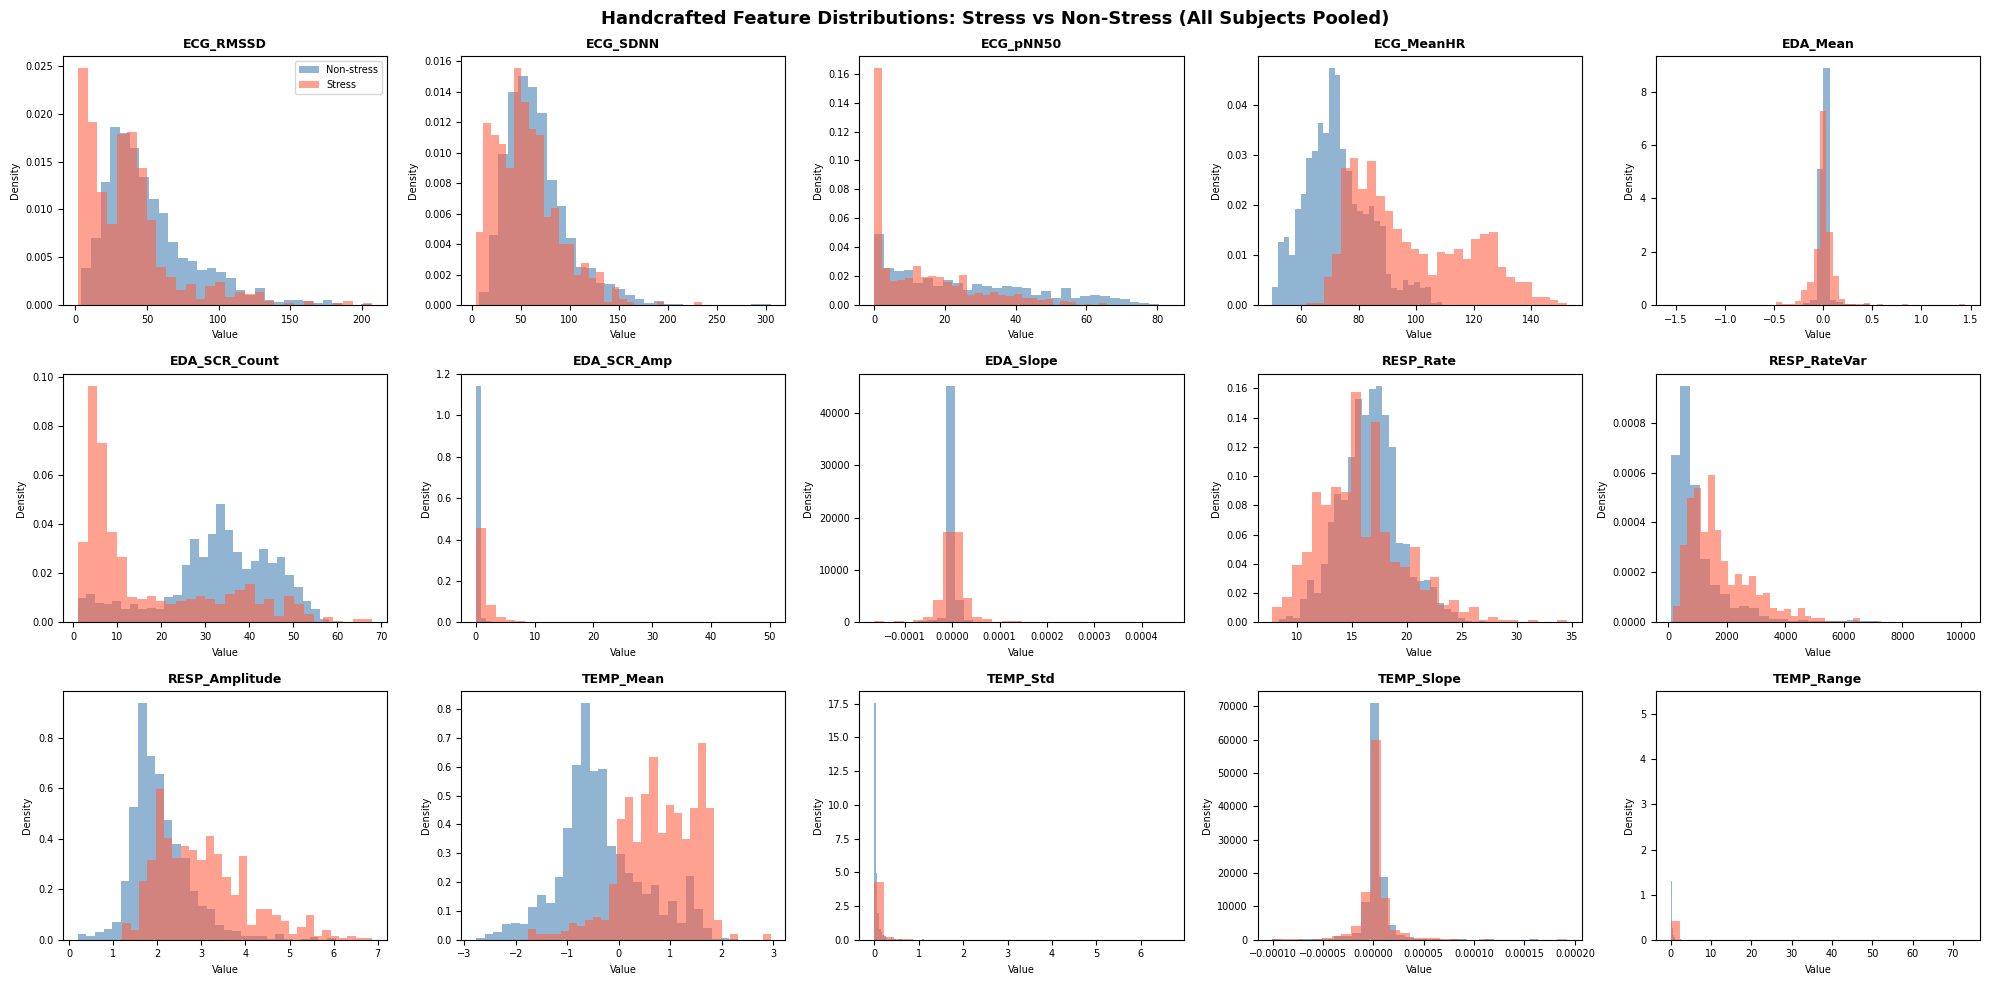

Saved: c:\Users\sanka\OneDrive\Desktop\mulitmodal stress detection\data\features\feature_distributions.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

all_X = []
all_y = []

for sid in SUBJECT_IDS:
    feat_path = FEATURES_DIR / f"S{sid}_features.npy"
    label_path = PROCESSED_DIR / f"S{sid}_y.npy"

    all_X.append(np.load(feat_path))
    all_y.append(np.load(label_path))

all_X = np.vstack(all_X)
all_y = np.concatenate(all_y)

print(
    f"Pooled dataset: {all_X.shape[0]} windows, "
    f"{all_X.shape[1]} features"
)

print(
    f"Stress: {(all_y == 1).sum()}, "
    f"Non-stress: {(all_y == 0).sum()}"
)

fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.flatten()

stress_idx = all_y == 1
nonstress_idx = all_y == 0

for i, (ax, fname) in enumerate(zip(axes, feature_names_flat)):
    stress_values = all_X[stress_idx, i]
    nonstress_values = all_X[nonstress_idx, i]

    ax.hist(
        nonstress_values,
        bins=30,
        alpha=0.6,
        color="steelblue",
        label="Non-stress",
        density=True,
    )

    ax.hist(
        stress_values,
        bins=30,
        alpha=0.6,
        color="tomato",
        label="Stress",
        density=True,
    )

    ax.set_title(fname, fontsize=9, fontweight="bold")
    ax.set_xlabel("Value", fontsize=7)
    ax.set_ylabel("Density", fontsize=7)
    ax.tick_params(labelsize=7)

    if i == 0:
        ax.legend(fontsize=7)

fig.suptitle(
    "Handcrafted Feature Distributions: Stress vs Non-Stress (All Subjects Pooled)",
    fontsize=13,
    fontweight="bold",
)

plt.tight_layout()

plot_path = FEATURES_DIR / "feature_distributions.png"

plt.savefig(
    plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {plot_path}")

In [ ]:
def zero_modality_features(feature_vector: np.ndarray, modality_name: str) -> np.ndarray:
    
    modified = feature_vector.copy()
    modified[FEATURE_MODALITY_SLICES[modality_name]] = 0.0
    return modified

full_vec    = feats_s2_clean[0]
ecg_missing = zero_modality_features(full_vec, "ECG")

print("Full feature vector (first 4 = ECG features):")
print(f"  {full_vec[:4]}")
print("\nSame vector with ECG zeroed out:")
print(f"  {ecg_missing[:4]}")
print("\n→ All ECG HRV features become 0 — the classifier receives no heart rate info.")

In [ ]:
# Verification

In [ ]:
from pathlib import Path
import numpy as np

all_pass = True

# Check 1: Feature files exist
for sid in SUBJECT_IDS:
    path = FEATURES_DIR / f"S{sid}_features.npy"

    if not path.exists():
        print(f"Missing: S{sid}_features.npy")
        all_pass = False

if all_pass:
    print(f"All {len(SUBJECT_IDS)} feature files found.")

# Check 2: Feature dimensions
shapes_ok = True

for sid in SUBJECT_IDS:
    f = np.load(FEATURES_DIR / f"S{sid}_features.npy")

    if f.shape[1] != 15:
        print(
            f"S{sid}: incorrect feature dimension "
            f"({f.shape[1]} instead of 15)"
        )
        shapes_ok = False

if shapes_ok:
    print("All feature arrays have shape (N, 15).")

# Check 3: Residual NaN values
nan_ok = True

for sid in SUBJECT_IDS:
    f = np.load(FEATURES_DIR / f"S{sid}_features.npy")

    if np.isnan(f).any():
        print(f"S{sid}: NaN values detected after imputation.")
        nan_ok = False

if nan_ok:
    print("No NaN values detected in feature arrays.")

# Check 4: Summary CSV
summary_path = FEATURES_DIR / "dataset_summary.csv"
csv_exists = summary_path.exists()

if csv_exists:
    print("dataset_summary.csv found.")
else:
    print("dataset_summary.csv not found.")

# Check 5: Feature distribution figure
plot_path = FEATURES_DIR / "feature_distributions.png"
plot_exists = plot_path.exists()

if plot_exists:
    print("feature_distributions.png found.")
else:
    print("feature_distributions.png not found.")

print("\n" + "=" * 50)

validation_passed = (
    all_pass
    and shapes_ok
    and nan_ok
    and csv_exists
    and plot_exists
)

print(f"Validation status: {'PASSED' if validation_passed else 'FAILED'}")

if validation_passed:
    print("Feature extraction outputs verified successfully.")
else:
    print("One or more validation checks failed.")

All 15 feature files found.
All feature arrays have shape (N, 15).
No NaN values detected in feature arrays.
dataset_summary.csv found.
feature_distributions.png found.

Validation status: PASSED
Feature extraction outputs verified successfully.
